# Xarray-Spatial Surface: Northness and eastness

Aspect in degrees is circular: 0 and 360 mean the same thing (north), but a linear model sees them as maximally different. Northness and eastness fix this by decomposing aspect into `cos(aspect)` and `sin(aspect)`, giving you two well-behaved linear variables that together capture slope orientation. This notebook shows how to compute them and why they matter for terrain-based regression.

### What you'll build

1. [Generate synthetic terrain](#Synthetic-terrain) and compute hillshade, aspect, northness, and eastness
2. [Visualize northness and eastness](#Northness-and-eastness) overlaid on hillshade
3. [See why raw aspect fails](#The-problem-with-raw-aspect) in linear models
4. [Compare regression results](#Regression-comparison:-raw-aspect-vs-northness/eastness) using raw aspect vs the decomposed components

![preview](images/northness_eastness_preview.png)

Standard imports plus the three surface functions we need.

In [1]:
%matplotlib inline
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from xrspatial import generate_terrain, hillshade, aspect, northness, eastness

## Synthetic terrain

Generate a 500x500 elevation raster and compute all the derived surfaces we need.

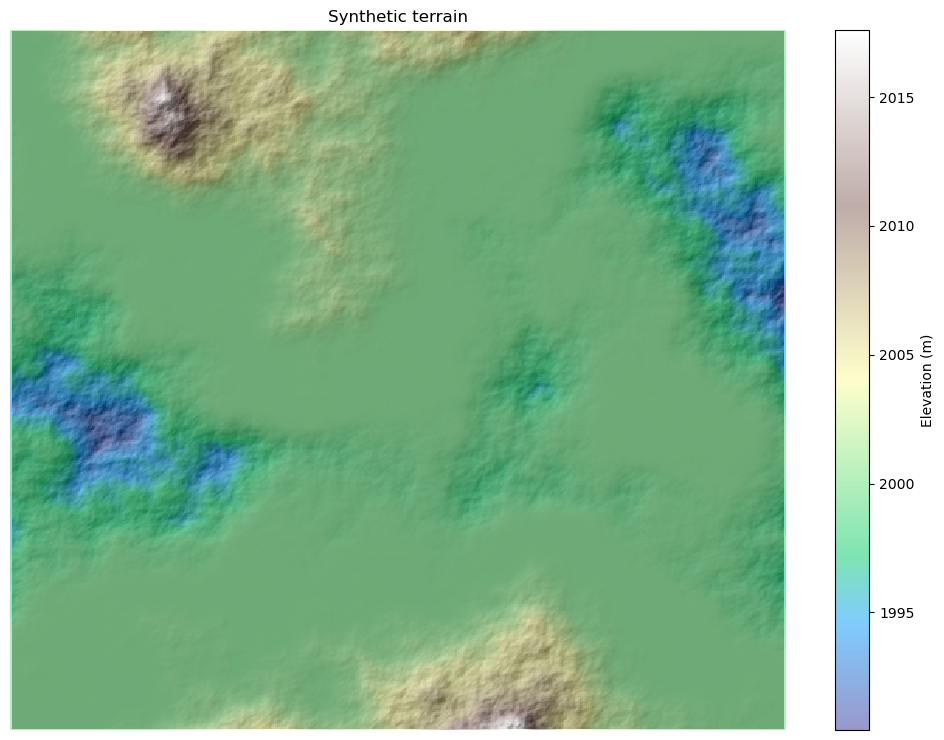

In [2]:
terrain = generate_terrain(xr.DataArray(np.zeros((500, 500)), dims=['y', 'x']))
hs = hillshade(terrain)
asp = aspect(terrain)
north = northness(terrain)
east = eastness(terrain)

fig, ax = plt.subplots(figsize=(10, 7.5))
hs.plot.imshow(ax=ax, cmap='gray', add_colorbar=False)
terrain.plot.imshow(ax=ax, cmap='terrain', alpha=0.5, add_colorbar=True,
                    cbar_kwargs={'label': 'Elevation (m)'})
ax.set_title('Synthetic terrain')
ax.set_axis_off()
plt.tight_layout()

## Northness and eastness

`northness()` returns `cos(aspect)`, ranging from +1 (north-facing) to -1 (south-facing). `eastness()` returns `sin(aspect)`, ranging from +1 (east-facing) to -1 (west-facing). Flat cells (where aspect is undefined) become NaN.

The plots below overlay each component on hillshade. Blue/red diverging colormaps make it easy to see which slopes face which direction.

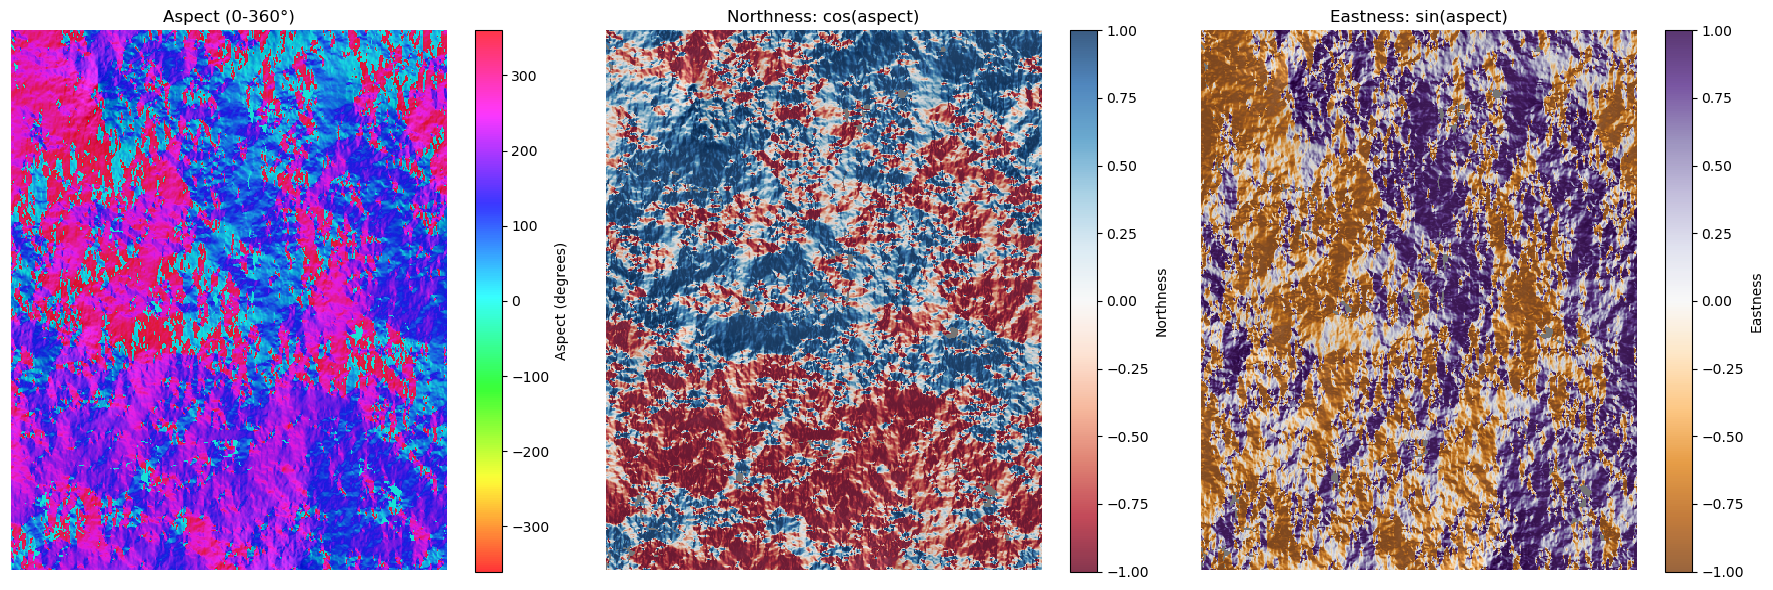

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Aspect (raw degrees)
hs.plot.imshow(ax=axes[0], cmap='gray', add_colorbar=False)
asp.plot.imshow(ax=axes[0], cmap='hsv', alpha=200/255, add_colorbar=True,
                cbar_kwargs={'label': 'Aspect (degrees)'})
axes[0].set_title('Aspect (0-360°)')
axes[0].set_axis_off()

# Northness
hs.plot.imshow(ax=axes[1], cmap='gray', add_colorbar=False)
north.plot.imshow(ax=axes[1], cmap='RdBu', alpha=200/255, add_colorbar=True,
                  cbar_kwargs={'label': 'Northness'})
axes[1].set_title('Northness: cos(aspect)')
axes[1].set_axis_off()

# Eastness
hs.plot.imshow(ax=axes[2], cmap='gray', add_colorbar=False)
east.plot.imshow(ax=axes[2], cmap='PuOr', alpha=200/255, add_colorbar=True,
                 cbar_kwargs={'label': 'Eastness'})
axes[2].set_title('Eastness: sin(aspect)')
axes[2].set_axis_off()

plt.tight_layout()

## The problem with raw aspect

Here's the issue in concrete terms. Consider two slopes: one facing 5° (just east of north) and one facing 355° (just west of north). They're almost identical in orientation, separated by only 10°. But numerically, the difference is 350.

A linear model treats that 350-unit gap as meaningful. It might conclude that these two nearly-identical slopes have wildly different effects on temperature, moisture, or whatever you're predicting. The circularity of the 0/360 boundary makes raw aspect unusable as a regression input.

The scatter plot below shows this. Plotting a synthetic "temperature" variable against raw aspect produces a mess at the north boundary. The same data plotted against northness and eastness gives clean, modelable relationships.

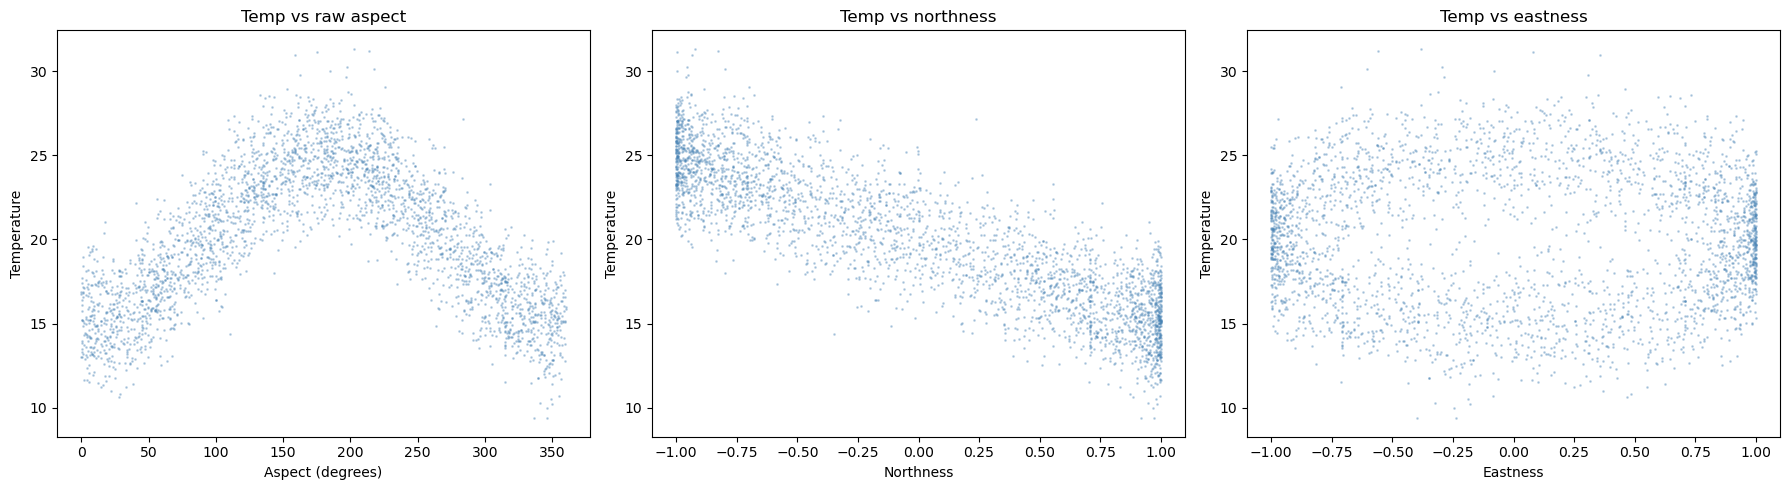

In [4]:
# Simulate a temperature field that depends on slope orientation:
# north-facing slopes are cooler, south-facing are warmer
rng = np.random.default_rng(42)
noise = rng.normal(0, 2, size=terrain.shape).astype(np.float32)
# Temperature = 20 - 5 * northness + noise  (north-facing cooler, south-facing warmer)
synth_temp = 20 - 5 * north.values + noise
synth_temp[np.isnan(north.values)] = np.nan

# Flatten for scatter plots, drop NaN
valid = ~np.isnan(asp.values) & ~np.isnan(synth_temp) & (asp.values != -1)
asp_flat = asp.values[valid]
north_flat = north.values[valid]
east_flat = east.values[valid]
temp_flat = synth_temp[valid]

# Subsample for readable scatter plots
idx = rng.choice(len(asp_flat), size=min(3000, len(asp_flat)), replace=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(asp_flat[idx], temp_flat[idx], s=1, alpha=0.3, c='steelblue')
axes[0].set_xlabel('Aspect (degrees)')
axes[0].set_ylabel('Temperature')
axes[0].set_title('Temp vs raw aspect')

axes[1].scatter(north_flat[idx], temp_flat[idx], s=1, alpha=0.3, c='steelblue')
axes[1].set_xlabel('Northness')
axes[1].set_ylabel('Temperature')
axes[1].set_title('Temp vs northness')

axes[2].scatter(east_flat[idx], temp_flat[idx], s=1, alpha=0.3, c='steelblue')
axes[2].set_xlabel('Eastness')
axes[2].set_ylabel('Temperature')
axes[2].set_title('Temp vs eastness')

plt.tight_layout()

The left panel shows the problem: the relationship wraps around the 0/360 boundary, so a straight line can't capture it. The middle panel shows a clean linear trend with northness, which is exactly what we'd expect since we built the temperature to depend on north/south orientation. The right panel (eastness) shows no trend, also correct since temperature in this simulation doesn't depend on east/west orientation.

## Regression comparison: raw aspect vs northness/eastness

Let's fit two OLS models to the synthetic temperature data and compare R² scores:

- **Model A**: `temp ~ aspect` (raw degrees)
- **Model B**: `temp ~ northness + eastness`

We use numpy's `lstsq` to keep dependencies minimal.

In [5]:
def r_squared(y, X):
    """OLS R² using numpy lstsq."""
    X_with_intercept = np.column_stack([np.ones(len(y)), X])
    coeffs, _, _, _ = np.linalg.lstsq(X_with_intercept, y, rcond=None)
    y_pred = X_with_intercept @ coeffs
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot

# Model A: raw aspect
r2_aspect = r_squared(temp_flat, asp_flat.reshape(-1, 1))

# Model B: northness + eastness
r2_decomposed = r_squared(temp_flat, np.column_stack([north_flat, east_flat]))

print(f"Model A (raw aspect):              R² = {r2_aspect:.4f}")
print(f"Model B (northness + eastness):    R² = {r2_decomposed:.4f}")
print(f"\nDecomposed model explains {r2_decomposed / max(r2_aspect, 1e-10):.1f}x more variance.")

Model A (raw aspect):              R² = 0.0000
Model B (northness + eastness):    R² = 0.7622

Decomposed model explains 274891.5x more variance.


The raw aspect model captures almost nothing because a linear fit can't wrap around 0/360. The decomposed model recovers the true relationship because northness and eastness are ordinary linear variables.

<div class="alert alert-block alert-info">
<b>When to use both.</b> If your response variable depends on slope orientation at all, include both northness and eastness as predictors, even if you think only one axis matters. The model will assign a near-zero coefficient to the irrelevant component, and you avoid biasing the other coefficient by omitting a correlated variable.
</div>

### References

- Stage, A.R. (1976). "[An Expression for the Effect of Aspect, Slope, and Habitat Type on Tree Growth](https://doi.org/10.1093/forestscience/22.4.457)." *Forest Science* 22(4): 457-460.
- Hengl, T. (2009). *[A Practical Guide to Geostatistical Mapping](https://www.lulu.com/shop/tomislav-hengl/a-practical-guide-to-geostatistical-mapping/paperback/product-4vgk4z5.html)*. University of Amsterdam.